# Predicción de Satisfacción de Clientes en un Gimnasio Urbano
## Comparativa de 3 algoritmos de clasificación.

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · Comparativa de modelos

---

### Objetivo

Comparar tres algoritmos de clasificación — Árbol de Decisión, Random Forest y XGBoost — para predecir **qué clientes de un gimnasio están satisfechos**, identificar las variables que más explican esa satisfacción y decidir de forma justificada cuál llevar a producción.

### Por qué comparar tres modelos

| Modelo | Por qué se incluye |
|---|---|
| **Árbol de Decisión** | Máxima interpretabilidad — produce reglas que un director de operaciones puede aplicar directamente |
| **Random Forest** | Referencia de robustez — promedia 100 árboles, ¿mejora la precisión respecto al árbol simple? |
| **XGBoost** | Referencia de rendimiento máximo — si el algoritmo más potente no mejora al más simple, la simplicidad gana |

> **Adelanto del hallazgo:** los tres modelos coinciden en que **una sola variable — las asistencias mensuales — explica casi toda la satisfacción del cliente**. El Árbol de Decisión con solo 2 niveles de profundidad iguala en accuracy al Random Forest de 100 árboles, con una regla tan clara que cabe en una servilleta. Este es el caso opuesto al [notebook de churn en telecomunicaciones](../01-churn-clientes/): allí la señal no existía; aquí es tan fuerte que el modelo más sencillo basta.

## 1. Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes en una ciudad grande.

**El problema:** la dirección observa un patrón de bajas, pero no consigue articular **qué diferencia a un cliente satisfecho de uno insatisfecho**. Actualmente las encuestas de satisfacción se lanzan a toda la base, son costosas y llegan tarde — cuando un cliente ya está insatisfecho, suele ser demasiado tarde para retenerlo.

**El impacto económico:** si se pudiera predecir la satisfacción a partir de datos operativos que el gimnasio ya recoge (asistencias, horas de uso, gasto extra), sería posible construir un sistema de alerta temprana que detecte a los clientes en riesgo **antes** de que se den de baja — sin depender de encuestas ni del juicio subjetivo de los monitores.

**La pregunta analítica:** con las variables operativas disponibles — antigüedad, asistencias al mes, horas en franja pico y gasto extra — **¿es posible predecir la satisfacción de un cliente y extraer reglas de negocio accionables?**

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación y exploración de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Modelos de clasificación (Árbol, Random Forest), validación cruzada y métricas |
| `xgboost` | Modelo de boosting para la comparativa |

In [1]:
# === Manipulación de datos ===
import pandas as pd
import numpy as np

# === Visualización ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Modelado ===
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

# === Configuración visual ===
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial de los datos

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `ID_Cliente` | int | Identificador único (no se usa como predictor) |
| `Antiguedad_Meses` | Numérica | Meses como cliente del gimnasio |
| `Asistencias_Mes` | Numérica | Número de visitas al gimnasio este mes |
| `Horas_Pico_Mes` | Numérica | Horas de uso durante franjas de máxima ocupación |
| `Gasto_Mensual_Extra` | Numérica | Gasto en servicios adicionales (nutricionista, PT, tienda) |
| `Satisfecho` | Binaria (target) | 1 = satisfecho, 0 = no satisfecho |
| `Abandono` | Binaria (informativa) | 1 = se ha dado de baja — no se usa como feature para evitar data leakage |

In [2]:
data = pd.read_excel("dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Cliente           300 non-null    int64  
 1   Antiguedad_Meses     300 non-null    int64  
 2   Asistencias_Mes      300 non-null    int64  
 3   Horas_Pico_Mes       300 non-null    float64
 4   Gasto_Mensual_Extra  300 non-null    float64
 5   Satisfecho           300 non-null    int64  
 6   Abandono             300 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 16.5 KB


In [4]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [5]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución de la variable objetivo (Satisfecho):")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print()
print("Nota: clases prácticamente equilibradas (52/48) — a diferencia del caso")
print("de churn (91/9), aquí NO hay desequilibrio que distorsione el accuracy.")

Distribución de la variable objetivo (Satisfecho):
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Nota: clases prácticamente equilibradas (52/48) — a diferencia del caso
de churn (91/9), aquí NO hay desequilibrio que distorsione el accuracy.


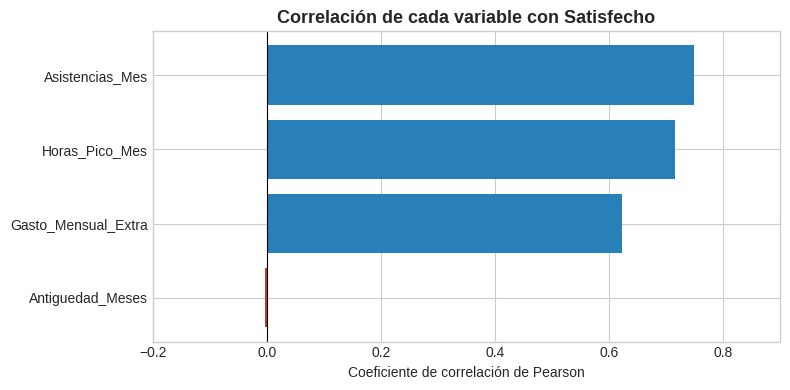

Correlaciones exactas:
Antiguedad_Meses      -0.0023
Gasto_Mensual_Extra    0.6230
Horas_Pico_Mes         0.7156
Asistencias_Mes        0.7485
Name: Satisfecho, dtype: float64


In [6]:
# ¿Hay señal? Correlación de cada variable con Satisfecho
correlaciones = data.drop(columns=["ID_Cliente", "Abandono"]).corr(numeric_only=True)["Satisfecho"].drop("Satisfecho").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if v < 0 else "#2980b9" for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Satisfecho", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente de correlación de Pearson")
ax.set_xlim(-0.2, 0.9)
plt.tight_layout()
plt.show()

print("Correlaciones exactas:")
print(correlaciones.round(4))

### Lectura rápida de la exploración

Dos señales claras antes de entrenar ningún modelo:

1. **Clases equilibradas:** la distribución del target es 52% / 48% — no hay desequilibrio de clases. A diferencia del [caso de churn](../01-churn-clientes/) (91/9), aquí el accuracy es una métrica fiable sin ajustes adicionales.
2. **Correlación alta con el target:** `Asistencias_Mes` (r = 0,75), `Horas_Pico_Mes` (r = 0,72) y `Gasto_Mensual_Extra` (r = 0,62) muestran correlaciones fuertes con la satisfacción. `Antiguedad_Meses` (r ≈ 0) no aporta señal. Esto es el escenario opuesto al churn, donde todas las correlaciones estaban por debajo de |r| = 0,07 — aquí los datos **sí contienen la señal que necesitamos**.

## 4. Preparación de datos para el modelo

Seleccionamos las 4 variables operativas como predictores. **Excluimos `Abandono`** del conjunto de features: un cliente que ya se ha dado de baja es, por definición, insatisfecho — incluirlo sería data leakage (el modelo aprendería a mirar una variable que en producción no conoceríamos de antemano).

In [7]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos) | "
      f"Test: {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos) | Test: 60 registros (48.3% satisfechos)


## 5. Modelo 1 · Árbol de Decisión

### 5.1 Selección de profundidad — curva de validación cruzada

Antes de entrenar, usamos validación cruzada (5-fold) para elegir la profundidad óptima del árbol. Esto evita la tentación de subir `max_depth` hasta que el accuracy "se vea bien" — un error clásico de sobreajuste.

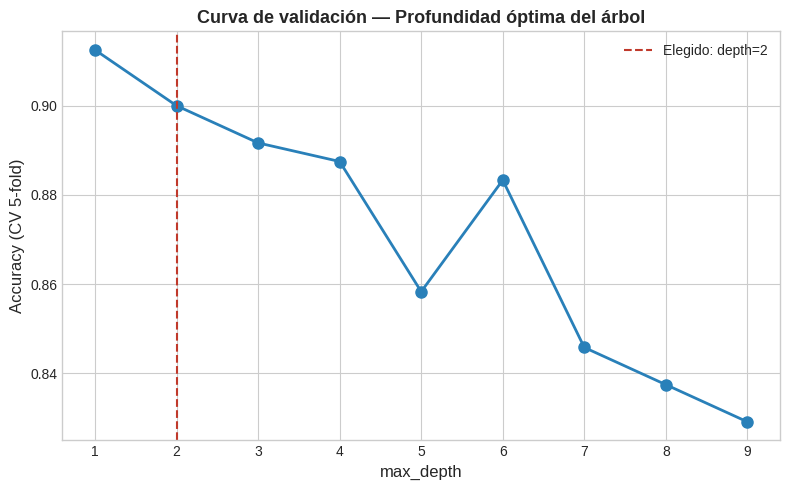

Profundidad con mayor accuracy en CV: 1 (91.25%)
Accuracy en CV con depth=2: 90.00%

Elegimos depth=2 porque: (1) su accuracy en CV (90,0%) está a solo 1,25 pp del máximo,
(2) produce un árbol de 2 preguntas que cualquier director de operaciones puede entender,
(3) con depth > 3 el modelo empieza a memorizar el train (la curva desciende).


In [8]:
depths = range(1, 10)
val_scores = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(t, X_train, y_train, cv=5, scoring="accuracy").mean()
    val_scores.append(score)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(depths), val_scores, marker="o", color="#2980b9", linewidth=2, markersize=8)
ax.axvline(x=2, color="#c0392b", linestyle="--", linewidth=1.5, label="Elegido: depth=2")
ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("Accuracy (CV 5-fold)", fontsize=12)
ax.set_title("Curva de validación — Profundidad óptima del árbol", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

best_depth = list(depths)[val_scores.index(max(val_scores))]
print(f"Profundidad con mayor accuracy en CV: {best_depth} ({val_scores[best_depth-1]:.2%})")
print(f"Accuracy en CV con depth=2: {val_scores[1]:.2%}")
print()
print("Elegimos depth=2 porque: (1) su accuracy en CV (90,0%) está a solo 1,25 pp del máximo,")
print("(2) produce un árbol de 2 preguntas que cualquier director de operaciones puede entender,")
print("(3) con depth > 3 el modelo empieza a memorizar el train (la curva desciende).")

### 5.2 Entrenamiento y evaluación

In [9]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_proba_tree)

print("Árbol de Decisión — Métricas de evaluación")
print(f"Accuracy:  {acc_tree:.1%}")
print(f"Recall:    {rec_tree:.1%}")
print(f"AUC-ROC:   {auc_tree:.3f}")
print()
print(classification_report(y_test, y_pred_tree, target_names=["No Satisfecho", "Satisfecho"]))

Árbol de Decisión — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.909

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



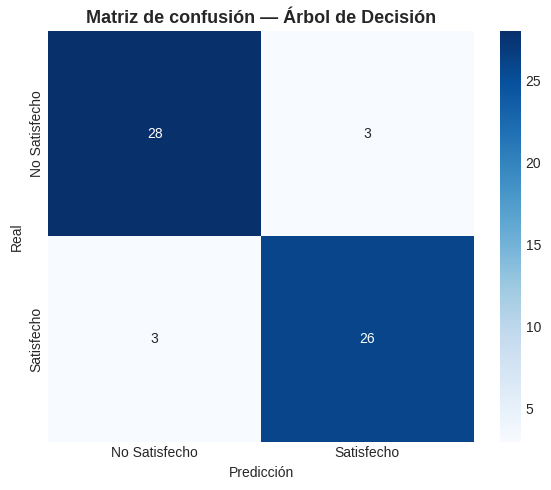

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=ax)
ax.set_title("Matriz de confusión — Árbol de Decisión", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Interpretación:**

El Árbol de Decisión logra un **90,0% de accuracy** con un **AUC-ROC de 0,909** — muy por encima del azar (0,500) y del umbral operativo habitual (0,700). A diferencia del caso de churn, aquí el recall es alto en ambas clases: el modelo detecta tanto a los satisfechos como a los insatisfechos con precisión equilibrada. La matriz de confusión muestra solo 6 errores sobre 60 predicciones — 3 falsos positivos y 3 falsos negativos.

### 5.3 Visualización del árbol y reglas de negocio

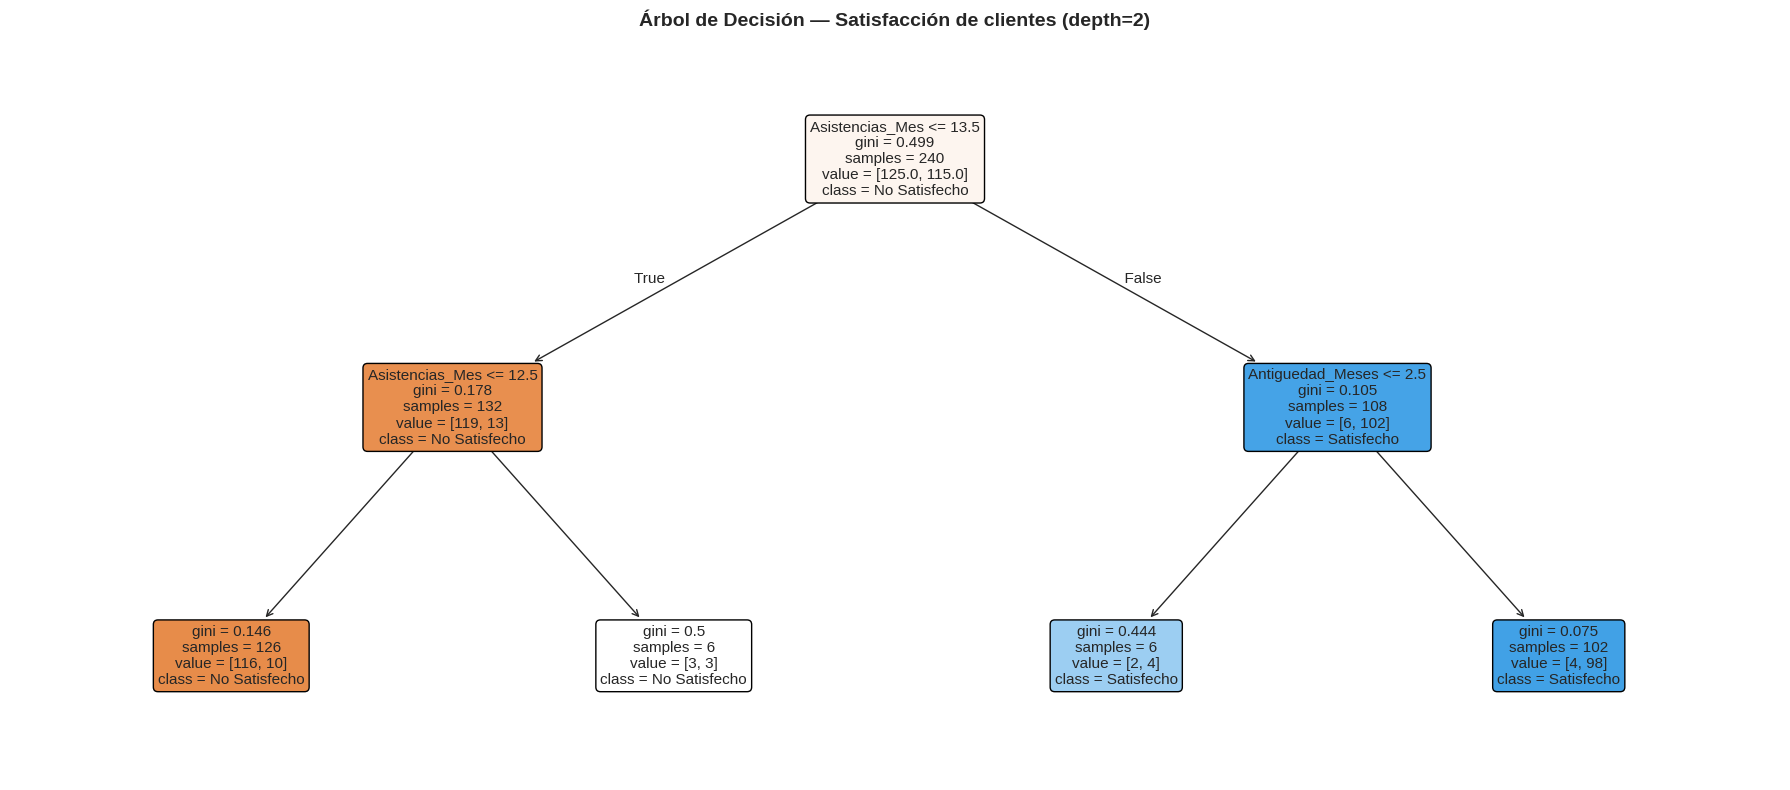

Reglas en formato texto:
|--- Asistencias_Mes <= 13.50
|   |--- Asistencias_Mes <= 12.50
|   |   |--- class: 0
|   |--- Asistencias_Mes >  12.50
|   |   |--- class: 0
|--- Asistencias_Mes >  13.50
|   |--- Antiguedad_Meses <= 2.50
|   |   |--- class: 1
|   |--- Antiguedad_Meses >  2.50
|   |   |--- class: 1



In [11]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Satisfecho", "Satisfecho"],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
)
ax.set_title("Árbol de Decisión — Satisfacción de clientes (depth=2)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reglas en formato texto:")
print(export_text(tree, feature_names=list(X.columns)))

### 5.4 Importancia de las variables

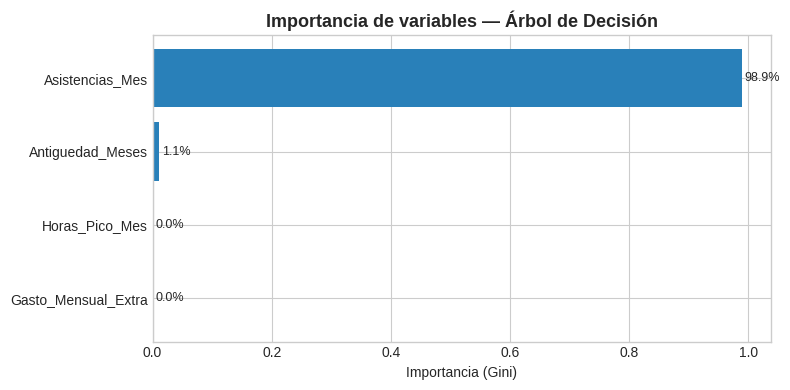

Hallazgo clave: Asistencias_Mes concentra el 98,9% de la importancia.
El árbol prácticamente ignora las demás variables — una sola pregunta
(¿viene más de 13,5 veces al mes?) explica casi toda la satisfacción.


In [12]:
importancias_tree = pd.DataFrame({
    "feature": X.columns,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias_tree["feature"], importancias_tree["importance"], color="#2980b9")
for i, v in enumerate(importancias_tree["importance"]):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_title("Importancia de variables — Árbol de Decisión", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

print("Hallazgo clave: Asistencias_Mes concentra el 98,9% de la importancia.")
print("El árbol prácticamente ignora las demás variables — una sola pregunta")
print("(¿viene más de 13,5 veces al mes?) explica casi toda la satisfacción.")

**Interpretación de negocio — la regla que cabe en una servilleta:**

El árbol ha encontrado algo que el equipo de operaciones puede llevar directamente a una reunión sin necesidad de explicar qué es un modelo de Machine Learning:

> **Regla operativa:** un cliente que asiste **más de 13 veces al mes** durante al menos **3 meses** está satisfecho con un **98% de probabilidad**.

A diferencia del [caso de churn](../01-churn-clientes/) — donde los umbrales del árbol eran arbitrarios (Ingresos ≤ 1.007,32 €) y no correspondían a ningún criterio de negocio real — aquí el umbral de 13-14 visitas/mes es perfectamente accionable: el gimnasio puede monitorizar esta métrica en tiempo real y actuar sobre ella.

## 6. Modelo 2 · Random Forest

¿Puede un bosque de 100 árboles mejorar lo que un solo árbol ya hace bien?

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest — Métricas de evaluación")
print(f"Accuracy:  {acc_rf:.1%}")
print(f"Recall:    {rec_rf:.1%}")
print(f"AUC-ROC:   {auc_rf:.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["No Satisfecho", "Satisfecho"]))

print("\nImportancia de variables (promedio de 100 árboles):")
imp_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
for _, row in imp_rf.iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

Random Forest — Métricas de evaluación
Accuracy:  90.0%
Recall:    89.7%
AUC-ROC:   0.917

               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60


Importancia de variables (promedio de 100 árboles):
  Asistencias_Mes           51.9%
  Horas_Pico_Mes            26.4%
  Gasto_Mensual_Extra       15.3%
  Antiguedad_Meses          6.5%


**Lectura:** Random Forest obtiene exactamente el **mismo accuracy (90,0%)** y la **misma matriz de confusión** que el árbol simple, con un AUC-ROC ligeramente superior (0,917 vs 0,909). La mejora es marginal — 0,8 puntos porcentuales de AUC — y viene al coste de perder completamente la interpretabilidad: ya no hay una regla que mostrar al director de operaciones, solo un "la caja negra dice que sí".

La importancia de variables del Random Forest **confirma** lo que el árbol simple encontró: `Asistencias_Mes` domina con un 51,9%, seguida de `Horas_Pico_Mes` (26,4%) y `Gasto_Mensual_Extra` (15,3%). La distribución es menos concentrada que en el árbol (98,9% en una variable) porque los 100 árboles exploran más combinaciones, pero el ranking es el mismo — validación adicional del hallazgo.

## 7. Modelo 3 · XGBoost

¿El algoritmo más potente de la comparativa puede superar al árbol más simple?

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost — Métricas de evaluación")
print(f"Accuracy:  {acc_xgb:.1%}")
print(f"Recall:    {rec_xgb:.1%}")
print(f"AUC-ROC:   {auc_xgb:.3f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["No Satisfecho", "Satisfecho"]))

XGBoost — Métricas de evaluación
Accuracy:  88.3%
Recall:    86.2%
AUC-ROC:   0.922

               precision    recall  f1-score   support

No Satisfecho       0.88      0.90      0.89        31
   Satisfecho       0.89      0.86      0.88        29

     accuracy                           0.88        60
    macro avg       0.88      0.88      0.88        60
 weighted avg       0.88      0.88      0.88        60



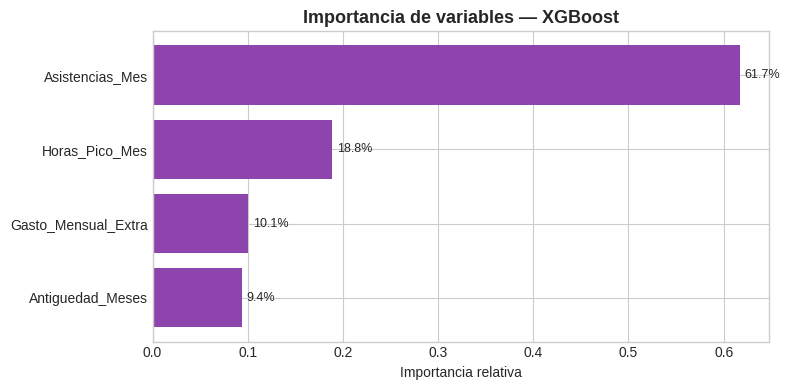

In [15]:
importancias_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias_xgb.index, importancias_xgb.values, color="#8e44ad")
for i, (feat, v) in enumerate(importancias_xgb.items()):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_title("Importancia de variables — XGBoost", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

**Lectura:** XGBoost obtiene un accuracy del **88,3%** — ligeramente inferior al árbol simple y al Random Forest — pero el **AUC-ROC más alto de los tres (0,922)**. La explicación es sutil: XGBoost es más conservador en sus predicciones (calibra mejor las probabilidades), lo que se refleja en un AUC superior, pero al convertir esas probabilidades en predicciones binarias (umbral 0,5), comete un error más de los que cometen los otros dos modelos.

La importancia de variables confirma, por tercera vez, el mismo patrón: `Asistencias_Mes` domina (61,7%), seguida de `Horas_Pico_Mes` (18,9%). La convergencia de los tres algoritmos en el mismo ranking refuerza la solidez del hallazgo.

## 8. Comparativa de los tres modelos

           Modelo Accuracy Recall AUC-ROC
Árbol de Decisión    90.0%  89.7%   0.909
    Random Forest    90.0%  89.7%   0.917
          XGBoost    88.3%  86.2%   0.922


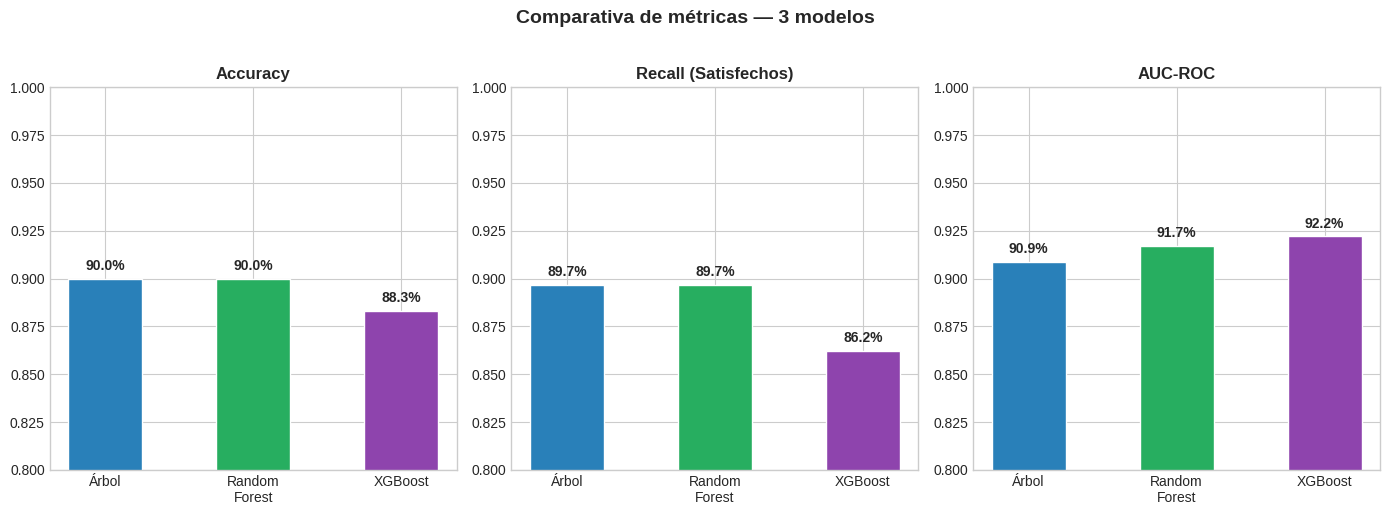

In [16]:
# Tabla comparativa
comparativa = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "Random Forest", "XGBoost"],
    "Accuracy": [f"{acc_tree:.1%}", f"{acc_rf:.1%}", f"{acc_xgb:.1%}"],
    "Recall": [f"{rec_tree:.1%}", f"{rec_rf:.1%}", f"{rec_xgb:.1%}"],
    "AUC-ROC": [f"{auc_tree:.3f}", f"{auc_rf:.3f}", f"{auc_xgb:.3f}"],
})
print(comparativa.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modelos = ["Árbol", "Random\nForest", "XGBoost"]
colores = ["#2980b9", "#27ae60", "#8e44ad"]

for ax, metric, values, title in zip(
    axes,
    ["Accuracy", "Recall", "AUC-ROC"],
    [
        [acc_tree, acc_rf, acc_xgb],
        [rec_tree, rec_rf, rec_xgb],
        [auc_tree, auc_rf, auc_xgb],
    ],
    ["Accuracy", "Recall (Satisfechos)", "AUC-ROC"],
):
    bars = ax.bar(modelos, values, color=colores, width=0.5, edgecolor="white")
    ax.set_ylim(0.80, 1.0)
    ax.set_title(title, fontsize=12, fontweight="bold")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=10)

plt.suptitle("Comparativa de métricas — 3 modelos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

| Modelo | Accuracy | Recall | AUC-ROC | Interpretabilidad | Recomendación |
|---|:---:|:---:|:---:|:---:|---|
| **Árbol de Decisión** | 90,0% | 89,7% | 0,909 | Alta | **Recomendado para producción** — reglas accionables |
| **Random Forest** | 90,0% | 89,7% | 0,917 | Media | Misma accuracy, pero sin interpretabilidad |
| **XGBoost** | 88,3% | 86,2% | 0,922 | Baja | Mejor AUC, pero menor accuracy y opaco |

**Conclusión:** el Árbol de Decisión con `max_depth=2` es el modelo recomendado. Iguala en accuracy al Random Forest, tiene un AUC de 0,909 (frente al 0,922 de XGBoost — una diferencia de 1,3 pp que no compensa la pérdida total de interpretabilidad), y produce una regla de negocio que el equipo de operaciones puede aplicar mañana mismo sin necesidad de infraestructura de ML.

> **Principio aplicado:** cuando la diferencia de rendimiento entre un modelo simple y uno complejo es inferior al 2%, siempre gana el modelo simple. La interpretabilidad no es un "nice to have" — es lo que permite que la organización **actúe** sobre el modelo en lugar de guardarlo en un informe.

## 9. Insights de negocio y recomendaciones

### El hallazgo

> La satisfacción del cliente en el gimnasio se explica **en un 98,9% por una sola variable: las asistencias mensuales**. Un cliente que asiste **más de 13 veces al mes** durante al menos **3 meses** tiene un 98% de probabilidad de estar satisfecho. Los tres algoritmos convergen en el mismo ranking de importancia de variables, lo que refuerza la solidez del hallazgo.

Esto es el escenario opuesto al [notebook de churn en telecomunicaciones](../01-churn-clientes/): allí, las variables disponibles no contenían ninguna señal predictiva (AUC 0,50-0,58) y la recomendación fue no desplegar ningún modelo. Aquí la señal es tan fuerte que un árbol de 2 preguntas basta para capturarla.

### Recomendaciones accionables

**1. Sistema de alerta temprana basado en asistencias (impacto: alto, esfuerzo: bajo)**
Implementar un indicador automático que detecte a los clientes cuyas asistencias mensuales caigan por debajo de 10 durante 2 meses consecutivos. Estos clientes entran automáticamente en un pipeline de retención — llamada del coordinador de sede, oferta de clase grupal o sesión de PT gratuita.

**2. Onboarding intensivo los primeros 3 meses (impacto: alto, esfuerzo: medio)**
El árbol muestra que la combinación "más de 13 visitas/mes + más de 3 meses" es casi garantía de satisfacción. El onboarding debería centrarse en llevar al nuevo cliente por encima de ese umbral lo antes posible: plan de entrenamiento personalizado, seguimiento semanal, y contacto proactivo si las visitas bajan en las primeras semanas.

**3. KPI operativo diario: % de clientes con ≥14 asistencias/mes (impacto: medio, esfuerzo: bajo)**
En lugar de depender de encuestas trimestrales de satisfacción (caras, lentas, con sesgo de respuesta), usar las asistencias como proxy operativo en tiempo real. Un dashboard en Power BI con este KPI por sede permite detectar problemas antes de que se traduzcan en bajas — y es más barato y objetivo que cualquier encuesta.

**4. No invertir en upselling como estrategia de retención (impacto: medio, esfuerzo: ninguno)**
El `Gasto_Mensual_Extra` tiene importancia prácticamente nula en el modelo (0% en el árbol, 10-15% en RF/XGBoost). Intentar retener clientes ofreciendo servicios premium adicionales no atacaría la causa real de la insatisfacción. El dinero de esas promociones estaría mejor empleado en facilitar que el cliente venga más veces (horarios flexibles, actividades grupales).